In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import sys
import warnings
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", SettingWithCopyWarning)

import numpy as np
import time, threading
import pandas as pd
import pynvml
import pandas as pd
import seaborn as sns
import jax
import functools
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc
import rapids_singlecell as rsc
import flax.linen as nn
import optax
import cellflow
from cellflow.model import CellFlow
import cellflow.preprocessing as cfpp
from cellflow.utils import match_linear
from cellflow.plotting import plot_condition_embedding
from cellflow.preprocessing import transfer_labels, compute_wknn, centered_pca, project_pca, reconstruct_pca
from cellflow.metrics import compute_r_squared, compute_e_distance


/home/icb/dominik.klein/mambaforge/envs/cellflow/lib/python3.12/site-packages/optuna/study/_optimize.py:29: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from optuna import progress_bar as pbar_module


In [2]:





def _to_str(x):
    return x.decode() if isinstance(x, (bytes, bytearray)) else str(x)

def nvml_handle(gpu_index=0):
    return pynvml.nvmlDeviceGetHandleByIndex(gpu_index)

def nvml_used_mb(h):
    return pynvml.nvmlDeviceGetMemoryInfo(h).used / 1024**2

class NVMLPeakSampler:
    def __init__(self, gpu_index=0, interval_s=0.01):
        self.h = nvml_handle(gpu_index)
        self.interval_s = interval_s
        self.samples = []
        self._stop = threading.Event()
        self._t = None

    def start(self):
        self.samples = []
        self._stop.clear()
        def loop():
            while not self._stop.is_set():
                self.samples.append((time.perf_counter(), nvml_used_mb(self.h)))
                time.sleep(self.interval_s)
        self._t = threading.Thread(target=loop, daemon=True)
        self._t.start()

    def stop(self):
        self._stop.set()
        if self._t is not None:
            self._t.join()

    def peak_mb(self):
        return max(m for _, m in self.samples) if self.samples else float("nan")

    def df(self):
        return pd.DataFrame(self.samples, columns=["t", "used_mb"])

def _to_str(x):
    return x.decode() if isinstance(x, (bytes, bytearray)) else str(x)


import pynvml
pynvml.nvmlInit()

def current_gpu_status(gpu_index=0):
    h = pynvml.nvmlDeviceGetHandleByIndex(gpu_index)
    name = _to_str(pynvml.nvmlDeviceGetName(h))
    mem = pynvml.nvmlDeviceGetMemoryInfo(h)
    util = pynvml.nvmlDeviceGetUtilizationRates(h)
    return {
        "gpu": gpu_index,
        "name": name,
        "memory_used_mb": mem.used / 1024**2,
        "memory_total_mb": mem.total / 1024**2,
        "memory_free_mb": mem.free / 1024**2,
        "utilization_gpu_pct": util.gpu,
        "utilization_mem_pct": util.memory,
    }

adata = sc.read_h5ad("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/pbmc_with_pca.h5ad")
adata.obsm["X_pca_simulated"] = adata.X[:,:100].copy()
adata.uns["donor_embeddings"] = {f"Donor{i}": np.random.normal(size=(2000,)) for i in range(1,13)}

adata.obs["condition"] = adata.obs.apply(lambda x: x["donor"] + "_" + x["cytokine"], axis=1)
adata.obs["is_control"] = adata.obs.apply(lambda x: True if x["cytokine"]=="PBS" else False, axis=1)

cf = CellFlow(adata, solver="otfm")
cf.prepare_data(
    sample_rep = "X_pca",
    control_key = "is_control",
    perturbation_covariates = {"cytokine_treatment": ("cytokine",)},
    perturbation_covariate_reps = {"cytokine_treatment": "esm2_embeddings"},
    sample_covariates = ["donor"],
    sample_covariate_reps = {"donor": "donor_embeddings"},
    split_covariates = ["donor"],
    max_combination_length = 1,
    null_value = 0.0,
)


layers_before_pool = {
    "cytokine_treatment": {"layer_type": "mlp", "dims": [1024, 1024], "dropout_rate": 0.5},
    "donor": {"layer_type": "mlp", "dims": [256, 256], "dropout_rate": 0.0},
}

layers_after_pool = {
    "layer_type": "mlp", "dims": [1024, 1024], "dropout_rate": 0.0,
}

match_fn = functools.partial(match_linear, epsilon=0.5, tau_a=1.0, tau_b=1.0)

cf.prepare_model(
    condition_mode="deterministic",
    regularization=0.0,
    pooling="attention_token",
    pooling_kwargs={},
    layers_before_pool=layers_before_pool,
    layers_after_pool=layers_after_pool,
    condition_embedding_dim=256,
    cond_output_dropout=0.9,
    condition_encoder_kwargs={},
    pool_sample_covariates=True,
    time_freqs=1024,
    time_encoder_dims=[1024, 1024, 1024],
    time_encoder_dropout=0.0,
    hidden_dims=[2048, 2048, 2048],
    hidden_dropout=0.0,
    conditioning="concatenation",
    decoder_dims=[4096, 4096, 4096],
    vf_act_fn=nn.silu,
    vf_kwargs=None,
    probability_path={"constant_noise": 0.5},
    match_fn=match_fn,
    optimizer=optax.MultiSteps(optax.adam(5e-5), 20),
    solver_kwargs={},
    layer_norm_before_concatenation=False,
    linear_projection_before_concatenation=False,
)

cf.train(
    num_iterations=2,
    batch_size=1,
    callbacks=[],
    valid_freq=30_000,
)
print("0", cf.dataloader.batch_size)


def benchmark_peak_gpu_mem(step_fn, cf_sampler, *, warmup=3, iters=10, gpu_index=0, sample_interval_s=0.01, label="run"):
    h = nvml_handle(gpu_index)
    rng_jax = jax.random.PRNGKey(0)
    rng_np = np.random.default_rng(0)

    
    for _ in range(warmup):
        rng_jax, rng_step_fn = jax.random.split(rng_jax, 2)
        batch = cf_sampler.sample(rng_np)
        loss = step_fn(rng_step_fn, batch)
        jax.block_until_ready(loss)

    baseline_mb = nvml_used_mb(h)

    # Measure peak during multiple steady-state iterations
    sampler = NVMLPeakSampler(gpu_index=gpu_index, interval_s=sample_interval_s)
    sampler.start()
    t0 = time.perf_counter()
    for _ in range(iters):
        rng_jax, rng_step_fn = jax.random.split(rng_jax, 2)
        batch = cf_sampler.sample(rng_np)
        loss = step_fn(rng_step_fn, batch)
        jax.block_until_ready(loss)
    t1 = time.perf_counter()
    sampler.stop()

    peak_mb = sampler.peak_mb()
    inc_peak_mb = peak_mb - baseline_mb

    summary = pd.DataFrame([{
        "label": label,
        "baseline_used_mb": baseline_mb,
        "peak_used_mb": peak_mb,
        "incremental_peak_mb": inc_peak_mb,
        "iters": iters,
        "sample_interval_ms": sample_interval_s * 1000,
        "elapsed_s": t1 - t0,
        "per_iter_ms": (t1 - t0) * 1000 / iters,
    }])

    return summary, sampler.df()


summaries = {}
for batch_size in [64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]:
    cf.dataloader.batch_size = batch_size
    summaries[batch_size] = benchmark_peak_gpu_mem(cf.solver.step_fn, cf.dataloader, warmup=3, iters=100, sample_interval_s=0.01, label="example")[0]



#summary.to_csv(f"/lustre/groups/ml01/workspace/ot_perturbation/results/profiling/gpu_mem_benchmark_batch_size_{batch_size}.csv", index=False)


[########################################] | 100% Completed | 144.92 ms
[########################################] | 100% Completed | 2.35 sms
[########################################] | 100% Completed | 621.01 ms


100%|██████████| 2/2 [00:06<00:00,  3.48s/it]


0 1


In [3]:
peak_mb = {k: v["peak_used_mb"] for k,v in summaries.items()}

In [4]:
df = pd.DataFrame.from_dict(peak_mb).T

In [5]:
df["MB"] = df[0]
df["batch_size"] = df.index

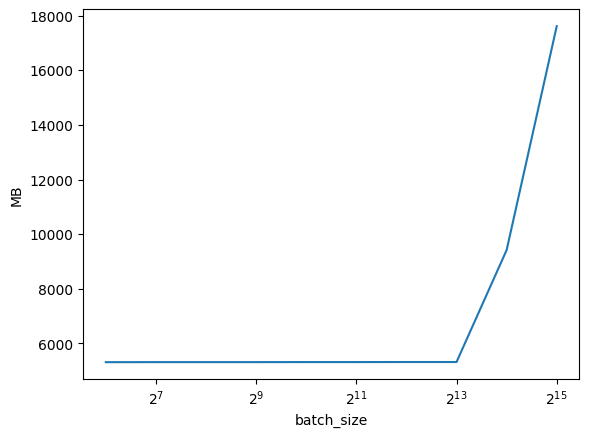

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.lineplot(data=df, x="batch_size", y="MB")
ax.set_xscale("log", base=2)

plt.show()


In [7]:
df.to_csv(f"/lustre/groups/ml01/workspace/ot_perturbation/results/profiling/gpu_mem_benchmark.csv", index=False)
